## WorldView Full-Scene DEMs vs. 3DEP Lidar: Atlanta and UCSD

The two full-scene benchmarks scored each site's DEMs against ICESat-2:
- [Atlanta](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_atlanta_full_benchmark.html): 21 DEMs from five same-pass WorldView-2 strips.
- [UCSD](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_ucsd_full_benchmark.html): 18 DEMs from five multi-date WorldView-3 scenes.

ICESat-2 is accurate but sparse: 14,000–38,000 shared points on stable terrain along about 100 beam tracks, which barely sample steep ground. This notebook scores the same 39 DEMs against **USGS 3DEP 1 m lidar DEMs**, millions of cells per DEM. It asks:
- Does a dense reference agree with ICESat-2 on the ranking and on the effect sizes?
- What does it show where ICESat-2 is thin: steep slopes at UCSD, and along-track patterns at Atlanta?

The lidar tiles were found with the [uw-cryo/stac-3dep-1m](https://github.com/uw-cryo/stac-3dep-1m) STAC catalog:

| site | 3DEP project | lidar flown | imagery | gap |
|---|---|---|---|---|
| UCSD | `San_Diego_CA_2014_LiDAR` (QL2) | 2014-10-27 to 2015-02-17 | 2014-11-09 to 2015-02-12 | **none**: same weeks |
| Atlanta | `GA_Statewide_2018_B18_DRRA`, with gaps filled by `GA_Central_2019_B19` | 2018-11-27 to 2020-06-14 | 2009-12-22 | 9–10 years |

**Method.**
- **Bare earth only.** The 3DEP 1 m products are bare-earth terrain models, and stereo makes surface models. So they are compared only on **open ground**: ESA WorldCover 2021 shrub, grass, crop, bare, wetland and moss. Trees, built-up and water are excluded.
- **Datum.** The 3DEP tiles are NAD83 UTM with NAVD88 heights; the realization and geoid model are not stated, so NAD83(2011) and NOAA GEOID12B (GEOID18 for the 2019 project) are assumed. GEOID18 instead of GEOID12B would move heights by under 3 cm here. They were converted to ITRF2014 ellipsoid heights in WGS84 UTM following UW-Cryo's [3D CRS Transformation Resources](https://uw-cryo.github.io/3D_CRS_Transformation_Resources/m-seamless/):
    - the NOAA geoid grid;
    - then the NAD83(2011) → ITRF2014 time-dependent Helmert at each site's median ICESat-2 epoch (2022.1 UCSD, 2022.9 Atlanta).

    That moves the lidar by about 1.4 m east and 0.7 m down at UCSD, and 1.4 m down at Atlanta, uniformly to within 1 cm over each site. The ground's own tectonic motion within NAD83 is not modelled; at San Diego it is a few decimeters.
- **Common frame.** The DEMs keep their benchmark alignment (`pc_align` translation to ICESat-2 on stable terrain). The lidar is **not** aligned: its datum transformation puts it in ICESat-2's frame, and ICESat-2 serves only as a check.
- **First version.** The first version of this notebook took NAD83 as WGS84 and removed the offset by aligning the lidar to ICESat-2. The last section shows what that changed.
- **Common grid.** Every DEM's aligned copy and the lidar (averaged from 1 m) are resampled to one grid per site, at the DEMs' posting: 1.9 m Atlanta, 1.2 m UCSD.
- **Residuals.** dh = DEM − lidar. Per DEM there is a 30-NMAD gross cut, then 3σ, as in `DEMBenchmark`.
- **Ranking.** DEMs are ranked on the **shared** open-ground cells, those valid in every DEM of the site.
- **Separability.** It uses the same paired block bootstrap as the benchmarks, on a 20 m lattice of those cells with 1 km blocks. Nearby cells are correlated, so the blocks, not the cell count, set the interval widths.

The rasters were processed on a compute node by `scripts/lidar/02_prep_lidar.py` and `03_compare.py` (in the repo's untracked `scripts/` folder). This notebook reads their tables and maps.

In [1]:
import glob, os, re
import numpy as np, pandas as pd, rasterio as rio
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from asp_plot.dem_benchmark import DEMBenchmark

SITES = {
    "Atlanta": dict(root="/nobackup/bpurint1/data/atlanta",
                    fb="/nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark"),
    "UCSD": dict(root="/nobackup/bpurint1/data/ucsd",
                 fb="/nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark"),
}
for s in SITES.values():
    s["cmp"] = f"{s['root']}/lidar/compare_recipe"   # lidar converted with the 3D CRS guide's recipe
    s["cmp_shortcut"] = f"{s['root']}/lidar/compare"  # first version: NAD83 taken as WGS84, lidar aligned to ICESat-2
    s["grid"] = f"{s['root']}/lidar/grid_recipe"
    s["stats"] = pd.read_csv(f"{s['cmp']}/stats.csv")
    s["by_slope"] = pd.read_csv(f"{s['cmp']}/by_slope.csv")
    s["by_class"] = pd.read_csv(f"{s['cmp']}/by_class.csv")
    s["along"] = pd.read_csv(f"{s['cmp']}/along_track.csv")

def describe(label):
    """(flow, convergence in degrees or NaN, short name) from a benchmark label folder name."""
    m = re.match(r"(raw_)?pair_(.+)-(.+)_([0-9.]+)$", label)
    if m:
        return ("raw pair" if m[1] else "map pair"), float(m[4]), f"{m[2]}-{m[3]}"
    if label.startswith("MVS"):
        return "multi-view", np.nan, label.replace("MVS_5_", "MVS ")
    return "blend", np.nan, label.replace("_", " ")

def dem_path(fb, label):
    """Original DEM of a label (the cached pc_align run under fb/dem_benchmark/<label>/ is reused)."""
    flow, _, name = describe(label)
    if flow.endswith("pair"):
        a, b = name.split("-")
        d = "raw" if flow == "raw pair" else "map"
        for x, y in ((a, b), (b, a)):
            fn = f"{fb}/{d}/stereo_pair_{x}_{y}/run-DEM.tif"
            if os.path.exists(fn):
                return fn
    if flow == "multi-view":
        ref = label.split("ref_")[1]  # Atlanta "nadir10" -> ref10, UCSD "n08" -> ref_n08
        return f"{fb}/map/stereo_mvs5_" + (f"ref{ref[5:]}" if ref.startswith("nadir") else f"ref_{ref}") + "/run-DEM.tif"
    n = label.split("_")[0]
    wide = "_15_" in label
    med = "median" in label
    stem = f"pairwise_wide{n}" if wide else f"pairwise{n}"
    return f"{fb}/map/{stem}{'_median' if med else ''}_mosaic-DEM.tif"

for name, s in SITES.items():
    s["stats"][["flow", "conv", "short"]] = s["stats"]["label"].apply(lambda l: pd.Series(describe(l)))
    s["stats"]["name"] = np.where(s["stats"].flow == "raw pair", "raw " + s["stats"].short, s["stats"].short)
    missing = [l for l in s["stats"]["label"] if not os.path.exists(dem_path(s["fb"], l))]
    print(name, len(s["stats"]), "DEMs; missing originals:", missing)

Atlanta 21 DEMs; missing originals: []
UCSD 18 DEMs; missing originals: []


### The lidar, and how well it agrees with ICESat-2

The converted lidar against ICESat-2 on open ground, **before** any alignment, checks the datum chain. The table also shows the shift a translation-only `pc_align` would apply, which is not applied here. The NMAD is the lidar's own disagreement with ICESat-2, a floor for every DEM score that follows. At Atlanta it includes up to 7 years of ICESat-2 time after a 2018–2020 survey.

In [2]:
rows = []
for name, s in SITES.items():
    for datum, d in (("recipe", "align_recipe"), ("first version (NAD83 as WGS84)", "align")):
        r = pd.read_csv(f"{s['root']}/lidar/{d}/lidar_vs_icesat2.csv").iloc[0]
        rows.append({"site": name, "lidar datum": datum, "ICESat-2 points (open ground)": int(r.n_points),
                     "median IS2 − lidar (m)": r.dh_median_m, "NMAD (m)": r.dh_nmad_m,
                     "pc_align would shift east / north / down (m)": f"{r.east_shift_m:+.2f} / {r.north_shift_m:+.2f} / {r.down_shift_m:+.2f}",
                     "NMAD after that shift (m)": r.dh_aligned_nmad_m})
pd.DataFrame(rows).set_index(["site", "lidar datum"]).round(2)

ICESat-2 points (open ground)  \
site    lidar datum                                                     
Atlanta recipe                                                  16854   
        first version (NAD83 as WGS84)                          16847   
UCSD    recipe                                                   6087   
        first version (NAD83 as WGS84)                           6086   

                                        median IS2 − lidar (m)  NMAD (m)  \
site    lidar datum                                                        
Atlanta recipe                                            0.10      0.36   
        first version (NAD83 as WGS84)                   -1.26      0.36   
UCSD    recipe                                            0.10      0.45   
        first version (NAD83 as WGS84)                   -0.63      0.45   

                                       pc_align would shift east / north / down (m)  \
site    lidar datum                                                                   
Atlanta recipe                                                -1.12 / +1.23 / +0.12   
        first version (NAD83 as WGS84)                        -0.33 / +0.07 / -1.24   
UCSD    recipe                                                +0.76 / +0.53 / +0.24   
        first version (NAD83 as WGS84)                        +0.56 / +0.14 / -0.49   

                                        NMAD after that shift (m)  
site    lidar datum                                                
Atlanta recipe                                               0.36  
        first version (NAD83 as WGS84)                       0.36  
UCSD    recipe                                               0.46  
        first version (NAD83 as WGS84)                       0.45

With the recipe, the lidar sits within 0.10 m of ICESat-2 vertically at both sites before any alignment. Taken as WGS84, NAD83 left it 0.63 m (UCSD) and 1.26 m (Atlanta) high.

The horizontal shifts `pc_align` proposes are not reliable, and the NMAD after the shift equals the NMAD without it. At Atlanta the proposed shift moves by 1.7 m between the two lidar versions, more than their actual 1.4 m difference. On mostly gentle open ground, ICESat-2's tracks barely constrain horizontal position, and the same holds for each DEM's own ICESat-2 alignment. The NMADs (0.36 m Atlanta, 0.45 m UCSD) include ICESat-2's own noise. They also include the land-cover mask's errors: WorldCover is from 2021, and an "open ground" cell can hold a shrub or a parked car.

Below are the lidar and the open-ground cells used, per site.

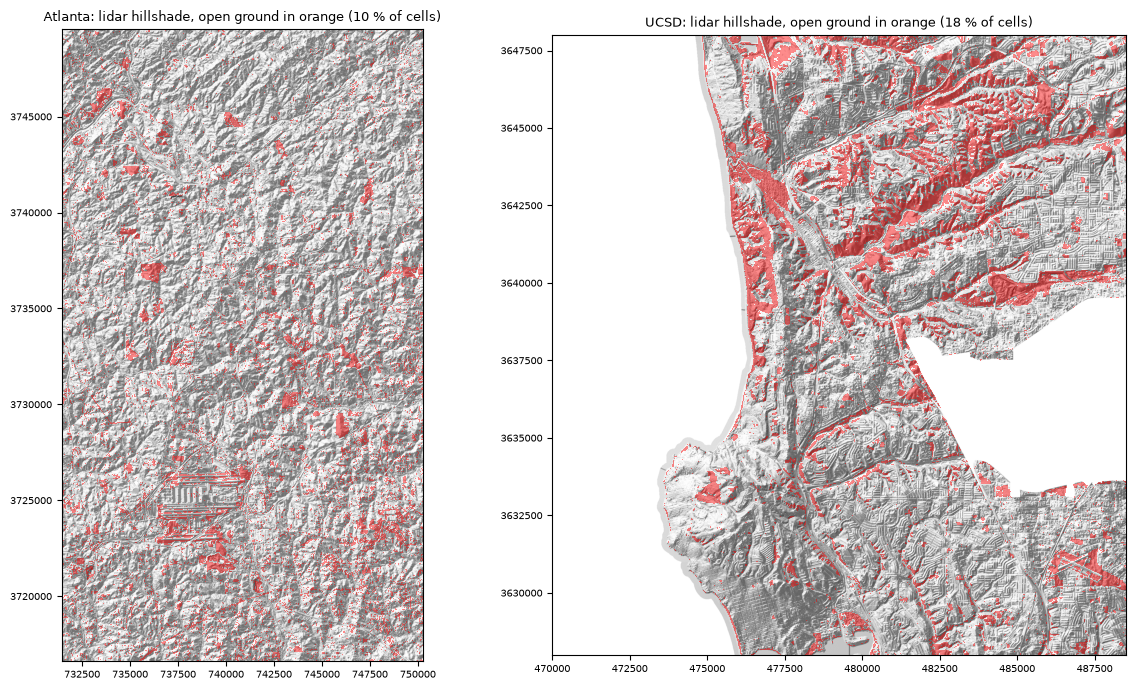

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7))
for ax, (name, s) in zip(axs, SITES.items()):
    g = s["grid"]
    with rio.open(f"{g}/lidar.tif") as ds:
        f = 8
        z = ds.read(1, out_shape=(ds.height // f, ds.width // f), resampling=Resampling.average, masked=True)
        ext = [ds.bounds.left, ds.bounds.right, ds.bounds.bottom, ds.bounds.top]
    with rio.open(f"{g}/worldcover.tif") as ds:
        wc = ds.read(1, out_shape=(ds.height // f, ds.width // f), resampling=Resampling.nearest)
    dx, dy = np.gradient(z.filled(np.nan), 8 * 1.9 if name == "Atlanta" else 8 * 1.2)
    hs = np.cos(np.arctan(np.hypot(dx, dy))) * 0.7 + 0.3 * np.cos(np.arctan2(dy, dx) - np.pi / 4)
    ax.imshow(hs, cmap="gray", extent=ext)
    og = np.isin(wc, [20, 30, 40, 60, 90, 100]) & ~z.mask
    ax.imshow(np.where(og, 1.0, np.nan), cmap="autumn", alpha=0.45, extent=ext, interpolation="nearest")
    ax.set_title(f"{name}: lidar hillshade, open ground in orange ({100 * og.sum() / (~z.mask).sum():.0f} % of cells)", fontsize=9)
    ax.ticklabel_format(style="plain"); ax.tick_params(labelsize=7)
plt.tight_layout()

### Rankings: lidar vs. ICESat-2

Each DEM is scored twice:
- **ICESat-2:** re-scored here from the cached `pc_align` runs with the benchmarks' settings (stable terrain, shared points), so the numbers are those of the two benchmark notebooks.
- **Lidar:** NMAD on the shared open-ground cells.

`lidar vs best` is the paired bootstrap 95 % interval on the DEM's lidar NMAD minus the best DEM's. An interval that includes 0 means the DEM is not separable from the best.

In [4]:
def icesat2_scores(name, s):
    labels = list(s["stats"]["label"])
    bench = DEMBenchmark(s["fb"], {l: dem_path(s["fb"], l) for l in labels},
                         parquet=f"{s['fb']}/atl06sr_all.parquet", filter_out=["water", "trees"],
                         n_bootstrap=0)
    bench.run(pc_align=True)
    return bench.stats_df.set_index("label")["dh_aligned_shared_nmad_m"], int(bench.stats_df["n_shared"].iloc[0])

import contextlib, io
for name, s in SITES.items():
    with contextlib.redirect_stdout(io.StringIO()):
        nm, n = icesat2_scores(name, s)
    s["stats"]["is2_nmad"] = s["stats"]["label"].map(nm)
    s["n_is2"] = n

def table(s):
    t = s["stats"].copy()
    t["lidar rank"] = t["shared_nmad"].rank().astype(int)
    t["ICESat-2 rank"] = t["is2_nmad"].rank().astype(int)
    t["lidar vs best (m)"] = [f"[{a:+.2f}, {b:+.2f}]" for a, b in zip(t.nmad_vs_best_ci_lo, t.nmad_vs_best_ci_hi)]
    return t[["name", "flow", "conv", "is2_nmad", "shared_nmad", "shared_median", "lidar vs best (m)", "p_best",
              "coverage_pct", "ICESat-2 rank", "lidar rank"]].rename(columns={
        "name": "DEM", "conv": "conv (°)", "is2_nmad": "ICESat-2 NMAD (m)", "shared_nmad": "lidar NMAD (m)",
        "shared_median": "lidar median (m)", "coverage_pct": "open-ground coverage (%)"}).round(2)

s = SITES["Atlanta"]
print(f"Atlanta: {s['stats'].shared_n.iloc[0]:,} shared open-ground cells "
      f"({s['stats'].shared_n.iloc[0] * 1.9**2 / 1e6:.1f} km²); {s['n_is2']:,} shared ICESat-2 points")
table(s)

Atlanta: 10,749,295 shared open-ground cells (38.8 km²); 38,305 shared ICESat-2 points


,DEM,flow,conv (°),ICESat-2 NMAD (m),lidar NMAD (m),lidar median (m),lidar vs best (m),p_best,open-ground coverage (%),ICESat-2 rank,lidar rank
0,raw 10-21,raw pair,31.7,0.76,0.61,0.25,"[+0.00, +0.00]",1.0,78.23,1,1
1,raw 13-10,raw pair,21.8,0.78,0.63,0.23,"[+0.01, +0.04]",0.0,84.85,3,2
2,raw 8-21,raw pair,27.0,0.78,0.63,0.28,"[+0.02, +0.04]",0.0,82.81,2,3
3,MVS ref_nadir10,multi-view,NaN,0.87,0.74,0.19,"[+0.11, +0.14]",0.0,87.77,5,4
4,6 pairs 15 mosaic,blend,NaN,0.86,0.74,0.21,"[+0.11, +0.15]",0.0,93.91,4,5
5,10-16,map pair,26.3,0.88,0.75,0.19,"[+0.12, +0.16]",0.0,80.17,8,6
6,13-10,map pair,21.8,0.89,0.75,0.18,"[+0.12, +0.16]",0.0,86.90,9,7
7,10 pairs median mosaic,blend,NaN,0.87,0.76,0.23,"[+0.13, +0.17]",0.0,98.17,6,8
8,MVS ref_nadir13,multi-view,NaN,0.88,0.76,0.20,"[+0.13, +0.17]",0.0,87.90,7,9
9,10-21,map pair,31.7,0.90,0.77,0.22,"[+0.14, +0.17]",0.0,79.95,10,10


In [5]:
s = SITES["UCSD"]
print(f"UCSD: {s['stats'].shared_n.iloc[0]:,} shared open-ground cells "
      f"({s['stats'].shared_n.iloc[0] * 1.2**2 / 1e6:.1f} km²); {s['n_is2']:,} shared ICESat-2 points")
table(s)

UCSD: 12,267,027 shared open-ground cells (17.7 km²); 14,237 shared ICESat-2 points


,DEM,flow,conv (°),ICESat-2 NMAD (m),lidar NMAD (m),lidar median (m),lidar vs best (m),p_best,open-ground coverage (%),ICESat-2 rank,lidar rank
0,10 pairs median mosaic,blend,NaN,1.07,0.81,-0.02,"[+0.00, +0.00]",0.55,98.08,3,1
1,n15-n24,map pair,17.5,1.11,0.81,0.07,"[-0.04, +0.04]",0.43,88.48,7,2
2,10 pairs mosaic,blend,NaN,1.03,0.84,0.10,"[-0.01, +0.06]",0.01,98.15,1,3
3,n24-n08,map pair,34.0,1.11,0.91,0.39,"[+0.06, +0.13]",0.00,83.76,8,4
4,nadir-n15,map pair,15.1,1.13,0.91,-0.45,"[+0.03, +0.17]",0.00,89.85,9,5
5,n24-n16,map pair,25.3,1.06,1.03,0.39,"[+0.17, +0.25]",0.00,88.82,2,6
6,8 pairs 15 mosaic,blend,NaN,1.13,1.05,-0.36,"[+0.18, +0.28]",0.00,97.79,11,7
7,raw n24-n16,raw pair,25.3,1.08,1.05,0.91,"[+0.16, +0.29]",0.00,84.47,4,8
8,8 pairs 15 median mosaic,blend,NaN,1.13,1.05,-0.34,"[+0.18, +0.28]",0.00,97.76,12,9
9,nadir-n24,map pair,26.0,1.16,1.06,0.26,"[+0.20, +0.30]",0.00,86.05,13,10


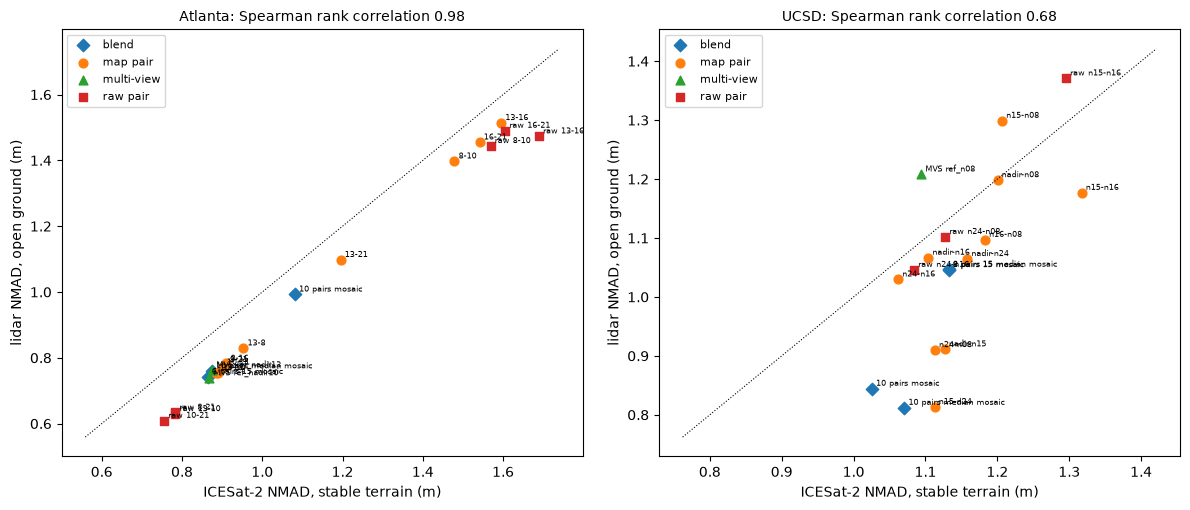

In [6]:
from scipy.stats import spearmanr
fig, axs = plt.subplots(1, 2, figsize=(12, 5.2))
mk = {"map pair": "o", "raw pair": "s", "multi-view": "^", "blend": "D"}
for ax, (name, s) in zip(axs, SITES.items()):
    t = s["stats"]
    for flow, g in t.groupby("flow"):
        ax.scatter(g.is2_nmad, g.shared_nmad, marker=mk[flow], label=flow, s=40)
        for _, r in g.iterrows():
            ax.annotate(r["name"], (r.is2_nmad, r.shared_nmad), fontsize=6, xytext=(3, 2), textcoords="offset points")
    lo, hi = min(t.is2_nmad.min(), t.shared_nmad.min()) - 0.05, max(t.is2_nmad.max(), t.shared_nmad.max()) + 0.05
    ax.plot([lo, hi], [lo, hi], "k:", lw=0.8)
    rho = spearmanr(t.is2_nmad, t.shared_nmad).statistic
    ax.set_title(f"{name}: Spearman rank correlation {rho:.2f}", fontsize=10)
    ax.set_xlabel("ICESat-2 NMAD, stable terrain (m)"); ax.set_ylabel("lidar NMAD, open ground (m)")
    ax.legend(fontsize=8)
plt.tight_layout()

### Convergence angle

Pair NMAD against convergence angle, lidar (filled) and ICESat-2 (hollow). Blends and multi-view runs are the horizontal lines.

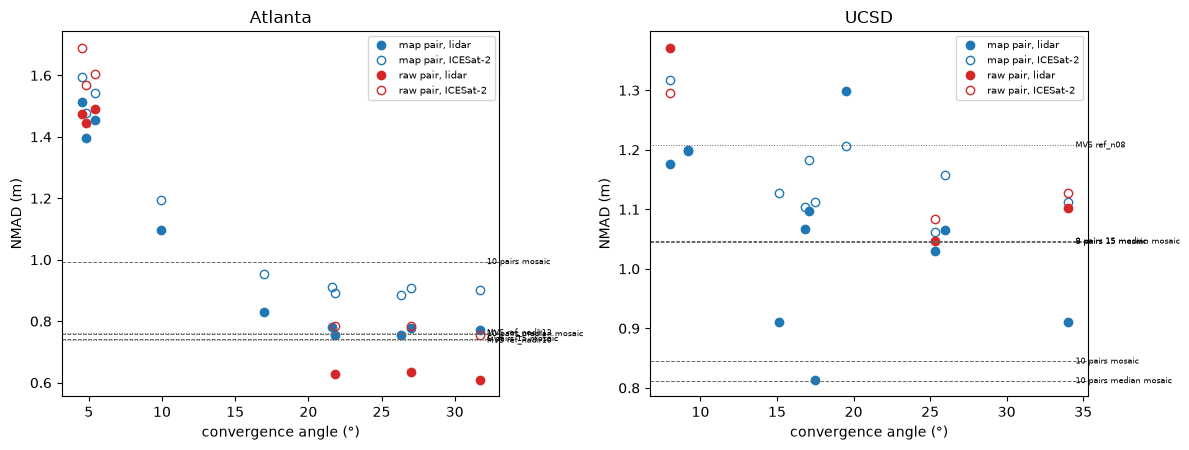

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.6), sharey=False)
for ax, (name, s) in zip(axs, SITES.items()):
    t = s["stats"]
    for flow, c in (("map pair", "C0"), ("raw pair", "C3")):
        g = t[t.flow == flow].sort_values("conv")
        ax.plot(g.conv, g.shared_nmad, "o", c=c, label=f"{flow}, lidar")
        ax.plot(g.conv, g.is2_nmad, "o", mfc="none", c=c, label=f"{flow}, ICESat-2")
    for _, r in t[t.flow.isin(["blend", "multi-view"])].iterrows():
        ax.axhline(r.shared_nmad, lw=0.7, ls="--" if r.flow == "blend" else ":", c="0.4")
        ax.text(t.conv.max() + 0.5, r.shared_nmad, r.short, fontsize=6, va="center")
    ax.set_title(name); ax.set_xlabel("convergence angle (°)"); ax.set_ylabel("NMAD (m)"); ax.legend(fontsize=7)
plt.tight_layout()

### Slope: where the dense reference adds most

ICESat-2 barely samples steep open ground, and the lidar covers all of it. Below is NMAD by lidar slope on the shared open-ground cells, for every pair. Next comes the raw − mapprojected difference for the pairs run both ways.

raw − map lidar NMAD (m) by slope class; negative = raw better


0-5  5-10  10-20  20-30  30-90
site    pair                                    
Atlanta 10-21   -0.16 -0.13  -0.10   0.04  -0.01
        13-10   -0.12 -0.12  -0.12  -0.04  -0.04
        13-16   -0.05 -0.01  -0.02  -0.02   0.07
        16-21    0.03  0.04   0.06   0.04   0.06
        8-10     0.04  0.06   0.10   0.16   0.19
        8-21    -0.15 -0.11  -0.07   0.09  -0.01
UCSD    n15-n16  0.18  0.13   0.11   0.18   0.39
        n24-n08  0.13  0.15   0.12   0.17   0.35
        n24-n16  0.07  0.04  -0.08  -0.23  -0.21

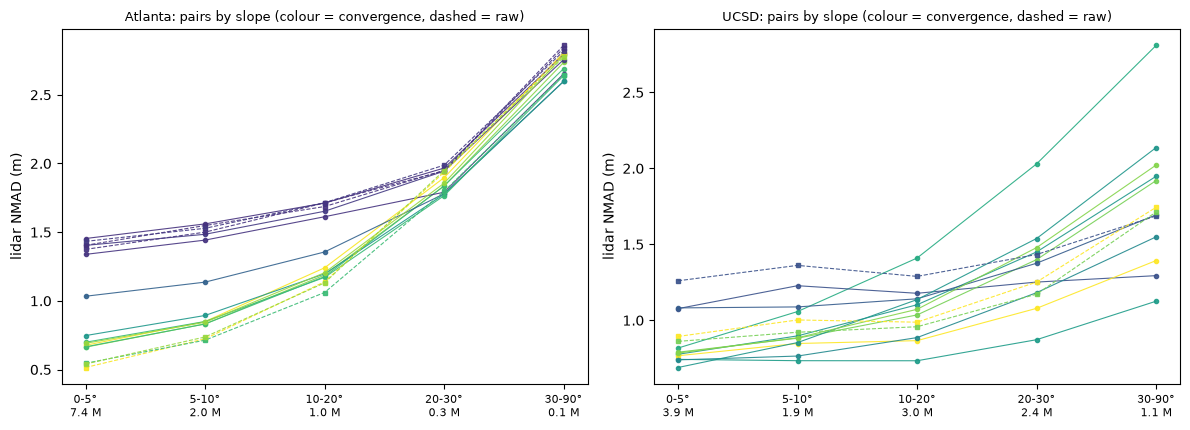

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, (name, s) in zip(axs, SITES.items()):
    bs = s["by_slope"].merge(s["stats"][["label", "flow", "short", "conv"]], on="label")
    order = ["0-5", "5-10", "10-20", "20-30", "30-90"]
    bs["x"] = bs.slope.map({k: i for i, k in enumerate(order)})
    bs = bs.sort_values("x")
    for (lab, flow), g in bs[bs.flow.str.endswith("pair")].groupby(["label", "flow"]):
        ax.plot(g.x, g.nmad, "-o" if flow == "map pair" else "--s", ms=3, lw=0.8,
                c=plt.cm.viridis(min(g.conv.iloc[0], 32) / 32), alpha=0.9)
    n = bs.groupby("slope").n.first().reindex(order)
    ax.set_xticks(range(len(n))); ax.set_xticklabels([f"{k}°\n{v / 1e6:.1f} M" for k, v in n.items()], fontsize=8)
    ax.set_title(f"{name}: pairs by slope (colour = convergence, dashed = raw)", fontsize=9); ax.set_ylabel("lidar NMAD (m)")
plt.tight_layout()

rows = []
for name, s in SITES.items():
    bs = s["by_slope"].merge(s["stats"][["label", "flow", "short"]], on="label")
    raw = bs[bs.flow == "raw pair"]
    for short in raw.short.unique():
        a, b = short.split("-")
        m = bs[(bs.flow == "map pair") & bs.short.isin([f"{a}-{b}", f"{b}-{a}"])]
        r = raw[raw.short == short]
        if m.empty:
            continue
        d = r.set_index("slope").nmad - m.set_index("slope").nmad
        rows.append({"site": name, "pair": short, **d.round(2).to_dict()})
print("raw − map lidar NMAD (m) by slope class; negative = raw better")
pd.DataFrame(rows).set_index(["site", "pair"])

### Land cover

NMAD per open-ground class, then the DSM − DTM median on trees and built-up cells. The second is not an error: it is how far the stereo surface sits above bare earth, shown for context.

In [9]:
for name, s in SITES.items():
    bc = s["by_class"].merge(s["stats"][["label", "name", "flow"]], on="label")
    best = s["stats"].sort_values("shared_nmad")["name"].iloc[:4].tolist()
    piv = bc[bc["name"].isin(best)].pivot(index="name", columns="class", values="nmad")
    piv = piv[[c for c in ["grass", "shrub", "crop", "bare", "wetland"] if c in piv]]
    ctx = bc[bc["name"].isin(best)].pivot(index="name", columns="class", values="median")[["trees", "built-up"]]
    cnt = bc[bc["name"] == best[0]].set_index("class").n
    print(f"{name}: cells per class ({best[0]}):", ", ".join(f"{k} {v / 1e6:.1f} M" for k, v in cnt.items() if v > 0))
    display(pd.concat({"NMAD on open ground (m)": piv, "median DSM − DTM (m)": ctx}, axis=1).loc[best].round(2))

Atlanta: cells per class (raw 10-21): grass 10.1 M, crop 0.2 M, bare 1.3 M, trees 57.4 M, built-up 34.5 M


NMAD on open ground (m)                            \
class                             grass shrub  crop  bare wetland   
name                                                                
raw 10-21                          0.62   NaN  0.90  0.72     NaN   
raw 13-10                          0.63   NaN  0.92  0.79    0.12   
raw 8-21                           0.67   NaN  0.95  0.83     NaN   
MVS ref_nadir10                    0.77   NaN  1.38  0.93    0.14   

                median DSM − DTM (m)           
class                          trees built-up  
name                                           
raw 10-21                       1.10     0.48  
raw 13-10                       1.49     0.52  
raw 8-21                        1.29     0.54  
MVS ref_nadir10                 2.66     0.60

UCSD: cells per class (10 pairs median mosaic): shrub 6.9 M, grass 9.6 M, crop 0.0 M, bare 1.5 M, wetland 0.5 M, trees 26.7 M, built-up 54.7 M


NMAD on open ground (m)                            \
class                                    grass shrub  crop  bare wetland   
name                                                                       
10 pairs median mosaic                    1.10  0.93  0.97  1.25    0.37   
n15-n24                                   1.02  0.87  0.95  1.20    0.37   
10 pairs mosaic                           1.10  0.95  1.00  1.29    0.41   
n24-n08                                   1.07  1.03  1.13  1.25    0.38   

                       median DSM − DTM (m)           
class                                 trees built-up  
name                                                  
10 pairs median mosaic                 1.47     0.71  
n15-n24                                1.48     0.73  
10 pairs mosaic                        1.34     0.73  
n24-n08                                2.14     1.12

### Difference maps

Block medians (16 × 16 cells, about 30 m at Atlanta and 19 m at UCSD) of DEM − lidar on open ground, for each site's best DEM, a narrow pair and a blend. Blank areas are trees, buildings, water, or outside the DEM.

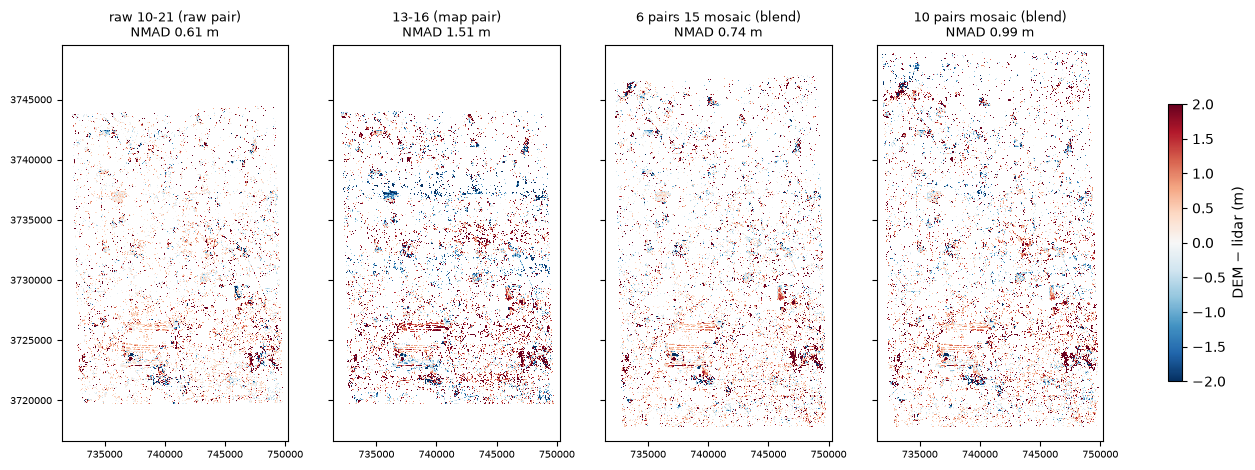

In [10]:
def show_maps(name, picks):
    s = SITES[name]
    fig, axs = plt.subplots(1, len(picks), figsize=(4.2 * len(picks), 6), sharey=True)
    for ax, lab in zip(axs, picks):
        with rio.open(f"{s['cmp']}/maps/{lab}.tif") as ds:
            a = ds.read(1); b = ds.bounds
        im = ax.imshow(a, cmap="RdBu_r", vmin=-2, vmax=2, extent=[b.left, b.right, b.bottom, b.top], interpolation="nearest")
        r = s["stats"].set_index("label").loc[lab]
        ax.set_title(f"{r['name']} ({r.flow})\nNMAD {r.shared_nmad:.2f} m", fontsize=9)
        ax.ticklabel_format(style="plain"); ax.tick_params(labelsize=7)
    fig.colorbar(im, ax=axs, shrink=0.6, label="DEM − lidar (m)")

t = SITES["Atlanta"]["stats"].sort_values("shared_nmad")
show_maps("Atlanta", [t.label.iloc[0], "pair_13-16_4.5", "6_pairs_15_mosaic", "10_pairs_mosaic"])

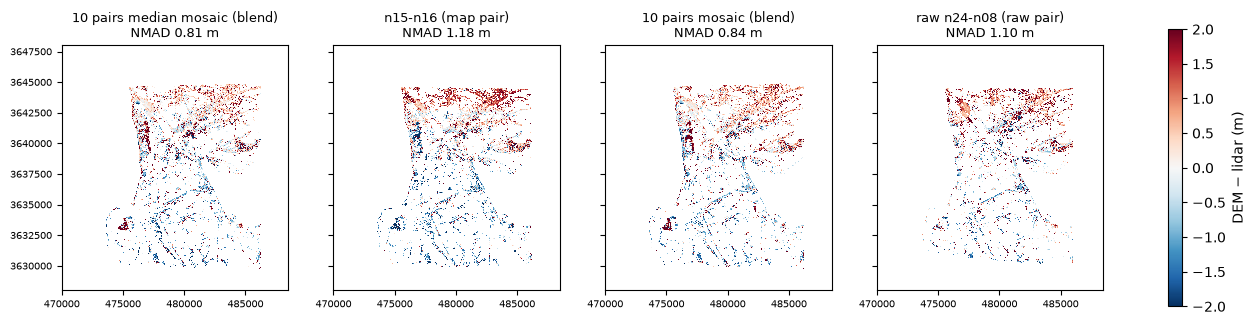

In [11]:
t = SITES["UCSD"]["stats"].sort_values("shared_nmad")
show_maps("UCSD", [t.label.iloc[0], "pair_n15-n16_8.0", "10_pairs_mosaic", "raw_pair_n24-n08_34.0"])

### Along-track pattern at Atlanta

The Atlanta strips run north–south, so northing is the along-track direction. The Atlanta benchmark's ICESat-2 residuals in 1 km bins showed a ±0.3 m along-track wave shared by every DEM. Below are lidar medians in 250 m bins of northing on the shared open ground. A wave shared by every DEM points to the images or the reference. Waves that differ between pairs point to per-scene attitude jitter, the subject of the Atlanta jitter experiment.

std of 250 m bin medians after removing a 2.25 km running median (m):
label
MVS_5_ref_nadir10         0.096
pair_10-21_31.7           0.098
raw_pair_10-21_31.7       0.100
10_pairs_median_mosaic    0.107
6_pairs_15_mosaic         0.107
MVS_5_ref_nadir13         0.108
raw_pair_13-10_21.8       0.110
pair_13-10_21.8           0.111
pair_10-16_26.3           0.114
pair_8-21_27.0            0.120
raw_pair_8-21_27.0        0.131
pair_8-16_21.6            0.138
pair_13-8_17.0            0.152
10_pairs_mosaic           0.183
pair_13-21_9.9            0.219
raw_pair_8-10_4.8         0.439
pair_16-21_5.4            0.443
raw_pair_13-16_4.5        0.443
pair_13-16_4.5            0.451
pair_8-10_4.8             0.494
raw_pair_16-21_5.4        0.501


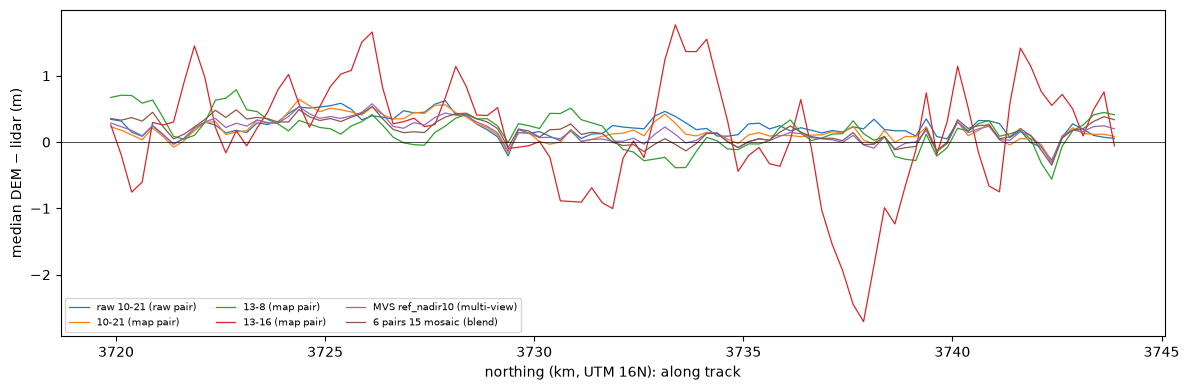

In [12]:
al = SITES["Atlanta"]["along"].merge(SITES["Atlanta"]["stats"][["label", "name", "flow"]], on="label")
picks = ["raw_pair_10-21_31.7", "pair_10-21_31.7", "pair_13-8_17.0", "pair_13-16_4.5", "MVS_5_ref_nadir10", "6_pairs_15_mosaic"]
fig, ax = plt.subplots(figsize=(12, 4))
for lab in picks:
    g = al[(al.label == lab) & (al.n > 2000)]
    r = g.iloc[0]
    ax.plot(g.northing / 1e3, g["median"], lw=0.9, label=f"{r['name']} ({r.flow})")
ax.axhline(0, c="k", lw=0.5); ax.set_xlabel("northing (km, UTM 16N): along track"); ax.set_ylabel("median DEM − lidar (m)")
ax.legend(fontsize=7, ncol=3); plt.tight_layout()
w = al[al.n > 2000].pivot(index="northing", columns="label", values="median")
hp = w - w.rolling(9, center=True, min_periods=3).median()
print("std of 250 m bin medians after removing a 2.25 km running median (m):")
print(hp.std().sort_values().round(3).to_string())

### Did the datum handling matter?

Below is each DEM's lidar NMAD with the recipe lidar against the first version (NAD83 taken as WGS84, then aligned to ICESat-2), on the same shared open-ground cells, then the difference by slope. A vertical offset cannot change an NMAD. A horizontal shift of the reference can, through the slopes.

In [13]:
rows, slope_rows = [], []
for name, s in SITES.items():
    a = pd.read_csv(f"{s['cmp_shortcut']}/stats.csv").set_index("label")
    b = s["stats"].set_index("label")
    d = pd.DataFrame({"DEM": b["name"], "first version": a.shared_nmad, "recipe": b.shared_nmad})
    d["recipe − first (m)"] = d["recipe"] - d["first version"]
    d["rank, first"] = d["first version"].rank().astype(int)
    d["rank, recipe"] = d["recipe"].rank().astype(int)
    rows.append(d.assign(site=name))
    x = pd.read_csv(f"{s['cmp_shortcut']}/by_slope.csv"); y = s["by_slope"]
    m = x.merge(y, on=["label", "slope"], suffixes=("_first", "_recipe"))
    m["diff"] = m.nmad_recipe - m.nmad_first
    g = m.groupby("slope", sort=False)["diff"].agg(["mean", "min", "max"]).reindex(["0-5", "5-10", "10-20", "20-30", "30-90"])
    slope_rows.append(g.assign(site=name))
    print(f"{name}: recipe − first NMAD {d['recipe − first (m)'].min():+.3f} to {d['recipe − first (m)'].max():+.3f} m; "
          f"Spearman between the two rankings {spearmanr(d['first version'], d['recipe']).statistic:.2f}")
display(pd.concat(slope_rows).reset_index().set_index(["site", "slope"]).round(3))
pd.concat(rows).reset_index(drop=True).set_index(["site", "DEM"]).sort_values(["site", "recipe"]).round(2)

Atlanta: recipe − first NMAD +0.001 to +0.011 m; Spearman between the two rankings 1.00
UCSD: recipe − first NMAD -0.105 to +0.102 m; Spearman between the two rankings 0.80


mean    min    max
site    slope                     
Atlanta 0-5    0.004  0.001  0.006
        5-10   0.015 -0.003  0.026
        10-20  0.016 -0.012  0.028
        20-30  0.063  0.027  0.120
        30-90  0.047 -0.043  0.093
UCSD    0-5    0.000 -0.012  0.012
        5-10   0.014 -0.046  0.066
        10-20  0.032 -0.124  0.154
        20-30  0.057 -0.245  0.254
        30-90  0.052 -0.475  0.340

first version  recipe  recipe − first (m)  \
site    DEM                                                                   
Atlanta raw 10-21                          0.60    0.61                0.01   
        raw 13-10                          0.62    0.63                0.01   
        raw 8-21                           0.63    0.63                0.01   
        MVS ref_nadir10                    0.73    0.74                0.01   
        6 pairs 15 mosaic                  0.73    0.74                0.01   
        10-16                              0.74    0.75                0.01   
        13-10                              0.75    0.75                0.01   
        10 pairs median mosaic             0.75    0.76                0.01   
        MVS ref_nadir13                    0.75    0.76                0.01   
        10-21                              0.76    0.77                0.01   
        8-21                               0.77    0.78                0.01   
        8-16                               0.77    0.78                0.01   
        13-8                               0.82    0.83                0.01   
        10 pairs mosaic                    0.99    0.99                0.01   
        13-21                              1.09    1.10                0.00   
        8-10                               1.39    1.40                0.01   
        raw 8-10                           1.44    1.44                0.01   
        16-21                              1.45    1.45                0.00   
        raw 13-16                          1.47    1.47                0.00   
        raw 16-21                          1.49    1.49                0.00   
        13-16                              1.51    1.51                0.00   
UCSD    10 pairs median mosaic             0.91    0.81               -0.10   
        n15-n24                            0.78    0.81                0.03   
        10 pairs mosaic                    0.80    0.84                0.04   
        n24-n08                            0.90    0.91                0.01   
        nadir-n15                          0.83    0.91                0.08   
        n24-n16                            0.95    1.03                0.08   
        8 pairs 15 mosaic                  1.14    1.05               -0.09   
        raw n24-n16                        1.15    1.05               -0.11   
        8 pairs 15 median mosaic           1.14    1.05               -0.09   
        nadir-n24                          0.98    1.06                0.09   
        nadir-n16                          0.96    1.07                0.10   
        n16-n08                            1.00    1.10                0.10   
        raw n24-n08                        1.18    1.10               -0.07   
        n15-n16                            1.23    1.18               -0.05   
        nadir-n08                          1.13    1.20                0.07   
        MVS ref_n08                        1.11    1.21                0.09   
        n15-n08                            1.20    1.30                0.10   
        raw n15-n16                        1.30    1.37                0.07   

                                  rank, first  rank, recipe  
site    DEM                                                  
Atlanta raw 10-21                           1             1  
        raw 13-10                           2             2  
        raw 8-21                            3             3  
        MVS ref_nadir10                     4             4  
        6 pairs 15 mosaic                   5             5  
        10-16                               6             6  
        13-10                               7             7  
        10 pairs median mosaic              8             8  
        MVS ref_nadir13                     9             9  
        10-21                              10            10  
        8-21                               11     

### Every DEM registered to the lidar

Each DEM's benchmark alignment is a translation to ICESat-2, which barely constrains horizontal position on gentle ground. On steep ground, a sub-meter offset then dominates slope-binned differences. So each DEM is registered here to the lidar itself:
- **The fit:** a translation-only `pc_align` (point-to-plane), with the lidar's open-ground cells as reference and the DEM's open-ground cells, on the site grid, as source (`04_register.py`).
- **Applying it:** the shift is applied to the whole DEM without resampling, and the dense comparison is repeated (`03_compare.py --tag lidarreg`).
- **The table:** each DEM's shift, which is how far its ICESat-2 alignment was off, and the NMAD before and after.

Three parameters fitted on millions of cells and scored on the same cells: in-sample, but negligibly so.

In [14]:
for name, s in SITES.items():
    s["reg"] = pd.read_csv(f"{s['root']}/lidar/register/registration.csv").set_index("label")
    s["stats_reg"] = pd.read_csv(f"{s['root']}/lidar/compare_lidarreg/stats.csv")
    s["by_slope_reg"] = pd.read_csv(f"{s['root']}/lidar/compare_lidarreg/by_slope.csv")

def reg_table(s):
    a = s["stats"].set_index("label"); b = s["stats_reg"].set_index("label"); r = s["reg"]
    t = pd.DataFrame({"DEM": a["name"], "flow": a["flow"], "shift east (m)": r.east_m, "shift north (m)": r.north_m,
                      "shift up (m)": r.up_m, "horizontal (m)": r.horizontal_m,
                      "NMAD, ICESat-2 aligned": a.shared_nmad, "NMAD, lidar registered": b.shared_nmad,
                      "median, lidar registered": b.shared_median, "p_best": b.p_best})
    t["vs best (95 %)"] = [f"[{x:+.2f}, {y:+.2f}]" for x, y in zip(b.nmad_vs_best_ci_lo, b.nmad_vs_best_ci_hi)]
    t["rank before"] = t["NMAD, ICESat-2 aligned"].rank().astype(int)
    t["rank after"] = t["NMAD, lidar registered"].rank().astype(int)
    return t.sort_values("NMAD, lidar registered")

for name, s in SITES.items():
    t = reg_table(s)
    print(f"{name}: horizontal shift to the lidar {t['horizontal (m)'].min():.2f}–{t['horizontal (m)'].max():.2f} m "
          f"(median {t['horizontal (m)'].median():.2f}); NMAD change "
          f"{(t['NMAD, lidar registered'] - t['NMAD, ICESat-2 aligned']).min():+.2f} to "
          f"{(t['NMAD, lidar registered'] - t['NMAD, ICESat-2 aligned']).max():+.2f} m; "
          f"Spearman with ICESat-2 {spearmanr(s['stats'].set_index('label').is2_nmad.reindex(t.index), t['NMAD, lidar registered']).statistic:.2f}")
    display(t.set_index("DEM").round(2))

Atlanta: horizontal shift to the lidar 1.52–3.36 m (median 2.26); NMAD change -0.05 to -0.02 m; Spearman with ICESat-2 0.97


,flow,shift east (m),shift north (m),shift up (m),horizontal (m),"NMAD, ICESat-2 aligned","NMAD, lidar registered","median, lidar registered",p_best,vs best (95 %),rank before,rank after
DEM,,,,,,,,,,,,
raw 10-21,raw pair,0.30,3.26,-0.31,3.27,0.61,0.56,-0.08,1.0,"[+0.77, +0.87]",1,1
raw 13-10,raw pair,0.25,3.10,-0.29,3.11,0.63,0.58,-0.08,0.0,"[+0.80, +0.89]",2,2
raw 8-21,raw pair,0.66,3.14,-0.32,3.20,0.63,0.59,-0.06,0.0,"[+0.86, +1.00]",3,3
MVS ref_nadir10,multi-view,0.44,2.00,-0.24,2.05,0.74,0.70,-0.06,0.0,"[+0.12, +0.16]",4,4
6 pairs 15 mosaic,blend,0.29,2.24,-0.25,2.26,0.74,0.71,-0.06,0.0,"[+0.02, +0.04]",5,5
13-10,map pair,0.44,2.63,-0.21,2.66,0.75,0.71,-0.04,0.0,"[+0.15, +0.18]",7,6
10-16,map pair,0.41,1.97,-0.22,2.01,0.75,0.72,-0.04,0.0,"[+0.13, +0.17]",6,7
MVS ref_nadir13,multi-view,0.16,2.22,-0.25,2.23,0.76,0.73,-0.07,0.0,"[+0.13, +0.16]",9,8
10-21,map pair,1.03,2.09,-0.23,2.33,0.77,0.73,-0.03,0.0,"[+0.14, +0.17]",10,9


UCSD: horizontal shift to the lidar 0.95–5.41 m (median 2.62); NMAD change -0.46 to -0.02 m; Spearman with ICESat-2 0.42


,flow,shift east (m),shift north (m),shift up (m),horizontal (m),"NMAD, ICESat-2 aligned","NMAD, lidar registered","median, lidar registered",p_best,vs best (95 %),rank before,rank after
DEM,,,,,,,,,,,,
nadir-n16,map pair,-3.38,1.86,0.28,3.86,1.07,0.69,0.13,1.0,"[+0.10, +0.22]",11,1
8 pairs 15 mosaic,blend,1.44,-3.92,0.00,4.18,1.05,0.74,0.03,0.0,"[+0.02, +0.09]",7,2
8 pairs 15 median mosaic,blend,1.48,-3.86,-0.01,4.14,1.05,0.74,0.04,0.0,"[+0.02, +0.08]",9,3
10 pairs median mosaic,blend,1.89,-0.42,0.01,1.93,0.81,0.75,0.05,0.0,"[+0.00, +0.00]",1,4
n15-n24,map pair,-0.34,0.89,0.07,0.95,0.81,0.76,0.05,0.0,"[+0.06, +0.13]",2,5
nadir-n15,map pair,-2.07,0.40,0.53,2.11,0.91,0.77,0.05,0.0,"[+0.11, +0.19]",5,6
10 pairs mosaic,blend,-0.45,0.93,0.03,1.04,0.84,0.78,0.05,0.0,"[+0.02, +0.07]",3,7
n16-n08,map pair,-2.88,2.25,0.27,3.65,1.10,0.79,0.09,0.0,"[+0.08, +0.14]",12,8
nadir-n24,map pair,-3.10,-0.28,-0.22,3.12,1.06,0.80,0.07,0.0,"[+0.19, +0.33]",10,9


In [15]:
rows = []
for name, s in SITES.items():
    bs = s["by_slope_reg"].merge(s["stats"][["label", "flow", "short"]], on="label")
    raw = bs[bs.flow == "raw pair"]
    for short in raw.short.unique():
        a, b = short.split("-")
        m = bs[(bs.flow == "map pair") & bs.short.isin([f"{a}-{b}", f"{b}-{a}"])]
        r = raw[raw.short == short]
        if m.empty:
            continue
        d = r.set_index("slope").nmad - m.set_index("slope").nmad
        allg = (s["stats_reg"].set_index("label").shared_nmad.loc[r.label.iloc[0]]
                - s["stats_reg"].set_index("label").shared_nmad.loc[m.label.iloc[0]])
        rows.append({"site": name, "pair": short, "all open ground": round(allg, 2), **d.round(2).to_dict()})
print("lidar-registered DEMs: raw − map lidar NMAD (m) by slope class; negative = raw better")
pd.DataFrame(rows).set_index(["site", "pair"])

lidar-registered DEMs: raw − map lidar NMAD (m) by slope class; negative = raw better


all open ground   0-5  5-10  10-20  20-30  30-90
site    pair                                                     
Atlanta 10-21              -0.17 -0.16 -0.15  -0.16  -0.32  -0.12
        13-10              -0.13 -0.12 -0.12  -0.14  -0.29  -0.10
        13-16              -0.04 -0.05 -0.01  -0.04  -0.10  -0.06
        16-21               0.03  0.03  0.04   0.05  -0.01   0.02
        8-10                0.04  0.03  0.03   0.06   0.05  -0.01
        8-21               -0.16 -0.15 -0.14  -0.15  -0.28  -0.13
UCSD    n15-n16             0.09  0.18  0.12   0.04   0.02   0.01
        n24-n08             0.11  0.12  0.12   0.08   0.11   0.21
        n24-n16             0.04  0.08  0.07   0.04  -0.01   0.00

Did the same horizontal shifts distort the **ICESat-2** benchmark scores? NMAD is blind to a constant vertical offset, so scoring the unaligned DEMs is equivalent to a vertical-only alignment. Below: shared-point ICESat-2 NMAD without alignment and after the benchmarks' `pc_align` (`05_is2_vertical_only.py`), next to the lidar-registered NMAD and the three rankings.

In [16]:
for name, s in SITES.items():
    v = pd.read_csv(f"{s['root']}/lidar/register/is2_vertical_only.csv").set_index("label")
    v["DEM"] = s["stats"].set_index("label")["name"]
    d = v.nmad_pc_align - v.nmad_unaligned
    print(f"{name}: pc_align changes ICESat-2 NMAD by {d.min():+.2f} to {d.max():+.2f} m; Spearman with the lidar-registered "
          f"ranking: unaligned {spearmanr(v.nmad_unaligned, v.lidar_registered).statistic:.2f}, "
          f"pc_align {spearmanr(v.nmad_pc_align, v.lidar_registered).statistic:.2f}")
    display(v.set_index("DEM")[["nmad_unaligned", "nmad_pc_align", "lidar_registered", "rank_unaligned", "rank_pc_align",
                                "rank_lidar_registered"]].sort_values("lidar_registered").round(2))

Atlanta: pc_align changes ICESat-2 NMAD by -0.02 to +0.00 m; Spearman with the lidar-registered ranking: unaligned 0.97, pc_align 0.97


,nmad_unaligned,nmad_pc_align,lidar_registered,rank_unaligned,rank_pc_align,rank_lidar_registered
DEM,,,,,,
raw 10-21,0.76,0.76,0.56,1,1,1
raw 13-10,0.80,0.78,0.58,3,3,2
raw 8-21,0.79,0.78,0.59,2,2,3
MVS ref_nadir10,0.87,0.87,0.70,4,5,4
6 pairs 15 mosaic,0.88,0.86,0.71,5,4,5
13-10,0.90,0.89,0.71,9,9,6
10-16,0.89,0.88,0.72,8,8,7
MVS ref_nadir13,0.89,0.88,0.72,7,7,8
10-21,0.90,0.90,0.73,10,10,9


UCSD: pc_align changes ICESat-2 NMAD by -0.03 to +0.06 m; Spearman with the lidar-registered ranking: unaligned 0.55, pc_align 0.40


,nmad_unaligned,nmad_pc_align,lidar_registered,rank_unaligned,rank_pc_align,rank_lidar_registered
DEM,,,,,,
nadir-n16,1.09,1.10,0.69,8,6,1
8 pairs 15 mosaic,1.07,1.13,0.74,4,11,2
8 pairs 15 median mosaic,1.07,1.13,0.74,6,12,3
10 pairs median mosaic,1.04,1.07,0.74,1,3,4
n15-n24,1.12,1.11,0.76,10,7,5
nadir-n15,1.15,1.13,0.77,13,9,6
10 pairs mosaic,1.04,1.03,0.78,2,1,7
n16-n08,1.16,1.18,0.79,14,14,8
nadir-n24,1.18,1.16,0.80,15,13,9


### Key takeaways

The 39 full-scene DEMs were scored on 3DEP lidar over open ground: 10.7 M shared cells (39 km²) at Atlanta and 12.3 M (18 km²) at UCSD. The lidar was converted to ITRF2014 ellipsoid heights with UW-Cryo's 3D CRS guide and sits within 0.10 m of ICESat-2 vertically without alignment. The headline numbers are for the DEMs registered to the lidar (last section). The earlier tables use the benchmarks' ICESat-2 alignment.

1. **The benchmarks' ICESat-2 alignment gets the heights right but not the horizontal position.**
    - At UCSD the per-DEM shift to the lidar is 0.95–5.4 m (median 2.6 m). It undoes, almost exactly, the horizontal part of each DEM's ICESat-2 `pc_align` (correlation −1.00 east, −0.98 north). Before that alignment the DEMs agreed with each other to 0.15–0.4 m.
    - At Atlanta, where ICESat-2 moved the DEMs little, they share a 1.3 m east, 2.4 m north offset from the lidar. That is the bundle-adjusted cameras' absolute position, which ICESat-2 cannot correct on flat ground.
    - The vertical scores are unaffected: dropping the alignment changes ICESat-2 NMADs by −0.03 to +0.06 m. Anyone differencing these DEMs against lidar or each other should register them first.
2. **At Atlanta, the lidar confirms the ICESat-2 benchmark** (rank correlation 0.97 with the registered ranking).
    - Raw wide pairs are best (0.56–0.59 m).
    - Multi-view, the 6-pair >15° blend and the 22–26° mapprojected pairs follow (0.70–0.73 m).
    - The plain 10-pair average is 0.97 m and the 4.5–5.4° pairs 1.38–1.48 m.
    - Registration lowers every NMAD by only 0.02–0.05 m.
3. **At UCSD, once registered, the ranking changes.**
    - NMADs fall by 0.02–0.46 m (largest for the DEMs ICESat-2 had shifted most).
    - The best DEM is the 17° pair nadir-n16 (0.69 m, first in every replicate).
    - Next come the 8-pair >15° blends (0.74 m), the 10-pair median blend (0.75 m) and n15-n24 (0.76 m). The plain 10-pair average is 0.78 m and the multi-view run 0.81 m. The narrow pairs and raw n15-n16 are 1.05–1.25 m.
    - **Dropping the narrow pairs no longer costs anything on the lidar**: the >15° blends edge the all-pairs blends. So the ICESat-2 benchmark's "average all the pairs" rule for a multi-date stack is not confirmed.
    - The ICESat-2 and lidar rankings agree only loosely (rank correlation 0.40–0.42 with alignment, 0.55 without). ICESat-2's stable terrain includes built-up ground and the lidar comparison does not, so the two score different surfaces.
    - The shared north–south tilt of the [UCSD benchmark](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_ucsd_full_benchmark.html) is still in these numbers, because registration is a translation.
4. **Raw against mapprojected, registered.**
    - Atlanta: raw is better on the three wide pairs by 0.13–0.17 m, at every slope class (by 0.28–0.32 m on 20–30°). On the ~5° pairs they are within ±0.04 m.
    - UCSD: mapprojected is better by 0.04 m (n24-n16), 0.09 m (n15-n16) and 0.11 m (n24-n08), mostly on gentle ground. Above 20° the difference is −0.01 to +0.21 m, with only n24-n08 clearly favouring mapprojection.
    - The large steep-slope mapprojection gain in this notebook's first version was a registration artefact.
5. **Along-track ripples at Atlanta grow as the base shrinks.** The short-scale variation in 250 m bins is about 0.1 m for wide pairs, 0.15 m at 17°, and 0.44–0.50 m for the 4.5–5.4° pairs. This is the height signature of attitude jitter. See the [Atlanta jitter notebook](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_atlanta_jitter.html), where solving for it removes 0.15–0.19 m of NMAD from the narrow pairs. Its lidar scores used the first-version lidar; at Atlanta that changes them by ≤ 0.011 m.
6. **The lidar's datum handling matters on steep ground only.** Against the first version (NAD83 taken as WGS84, lidar aligned to ICESat-2), the ICESat-2-aligned DEMs' NMADs change as follows:
    - Atlanta: +0.001 to +0.011 m;
    - UCSD: −0.10 to +0.10 m, nil on 0–5° ground and growing with slope.

**Caveats.**
- Only open ground is compared (10 % of Atlanta's lidar cells, 18 % of UCSD's), because the lidar is bare earth. Built-up ground, much of both scenes, is not scored here. A first-return lidar surface model would allow it.
- WorldCover is from 2021, so some "open ground" cells held something else on the image dates.
- Atlanta's lidar is 9–10 years after its imagery.
- The registration is fitted on the cells it is scored on: 3 parameters on millions of cells, so negligibly in-sample.
- Neither the lidar's NAD83 realization nor its geoid model is stated in the 3DEP metadata. The plausible choices differ by under 3 cm here. Tectonic motion at San Diego, not modelled, is a few decimeters horizontally.